In [ ]:
#import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score, precision_score

In [ ]:
#Load the dataset
df=pd.read_csv('/content/adult.csv')
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [ ]:
df.shape

(48842, 15)

In [ ]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [ ]:
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [ ]:
print("No of duplicate rows:",df.duplicated().sum())

No of duplicate rows: 52


In [ ]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


In [ ]:
# Feature summary panel
numerical_features = df.select_dtypes(include=['int64','float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns
print("Feature Summary:\n")
print("Numerical Features:")
for col in numerical_features:
    print("-", col)
print("\nCategorical Features:")
for col in categorical_features:
    print("-", col)

Feature Summary:

Numerical Features:
- age
- fnlwgt
- educational-num
- capital-gain
- capital-loss
- hours-per-week

Categorical Features:
- workclass
- education
- marital-status
- occupation
- relationship
- race
- gender
- native-country
- income


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# List of categorical columns to encode
categorical_cols_to_encode = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']

for col in categorical_cols_to_encode:
    if col in df.columns:
        df[col] = le.fit_transform(df[col])
    else:
        print(f"Column '{col}' not found in DataFrame.")

df['education'] = le.fit_transform(df['education'])

In [ ]:
# Target Column Encoding
df.columns = df.columns.str.strip()
# Only encode if the column is of 'object' (string) dtype
if 'income' in df.columns and df['income'].dtype == 'object':
    df['income'] = df['income'].str.strip().map({
    '<=50K': 0,
    '>50K': 1
    })
    print("Target column income encoded successfully")
else:
    print("Target column income is already encoded or does not exist.")

Target column income encoded successfully


In [ ]:
# Separate features and target
X = df.drop('income', axis=1)
y = df['income']

print("X and y created successfully")

X and y created successfully


In [ ]:
# Split the dataset into training and testing sets
x_train,x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
print("Dataset split into training and testing sets")

Dataset split into training and testing sets


In [ ]:
print("Dataset successfully split into training and testing sets")
print("Training set size:", x_train.shape)
print("Testing set size:", x_test.shape)

Dataset successfully split into training and testing sets
Training set size: (39073, 14)
Testing set size: (9769, 14)


In [ ]:
#model building
model=DecisionTreeClassifier(criterion='entropy')
model.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy')

In [ ]:
#predictions on test data
y_pred=model.predict(x_test)

In [ ]:
#evaluation metrics
confusion_matrix(y_test,y_pred)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

[[6542  889]
 [ 886 1452]]
              precision    recall  f1-score   support

           0       0.88      0.88      0.88      7431
           1       0.62      0.62      0.62      2338

    accuracy                           0.82      9769
   macro avg       0.75      0.75      0.75      9769
weighted avg       0.82      0.82      0.82      9769

0.8183027945542021


In [ ]:
# Training Accuracy
train_accuracy = model.score(x_train, y_train)
# Testing Accuracy
test_accuracy = model.score(x_test, y_test)
print("Training Accuracy: {:.2f}%".format(train_accuracy * 100))
print("Testing Accuracy: {:.2f}%".format(test_accuracy * 100))

Training Accuracy: 99.99%
Testing Accuracy: 81.83%


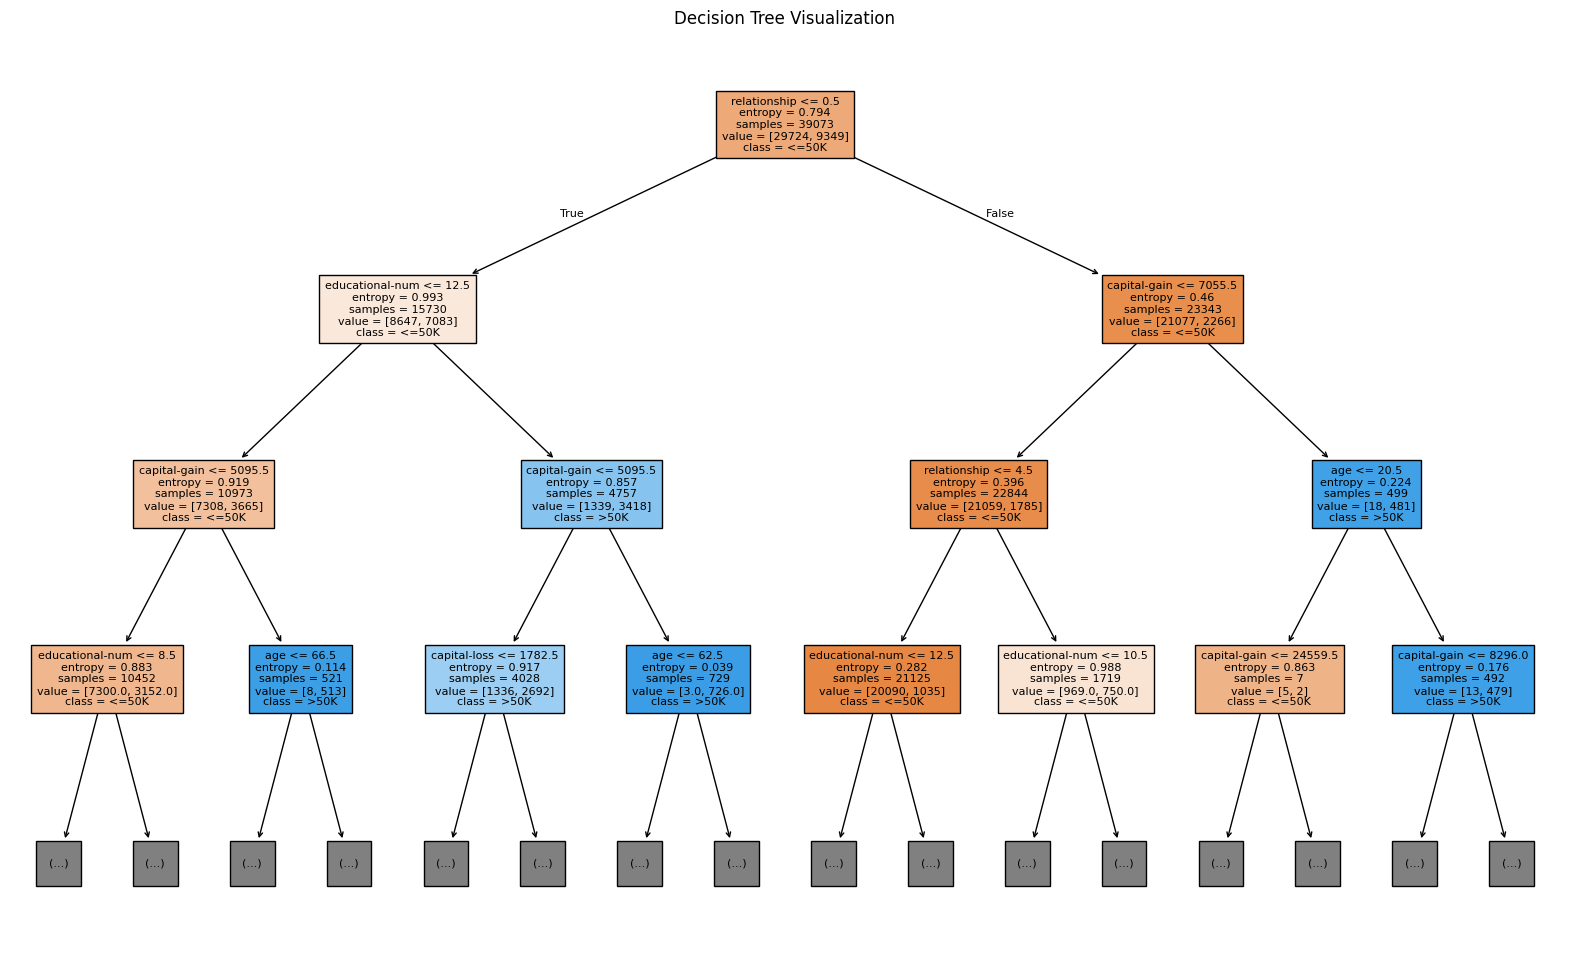

In [ ]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 12))

tree.plot_tree(
    model,
    max_depth=3,
    feature_names=X.columns,
    class_names=['<=50K', '>50K'], # Assuming these are the class names for 'income'
    filled=True,
    fontsize=8
)

plt.title("Decision Tree Visualization")
plt.show()

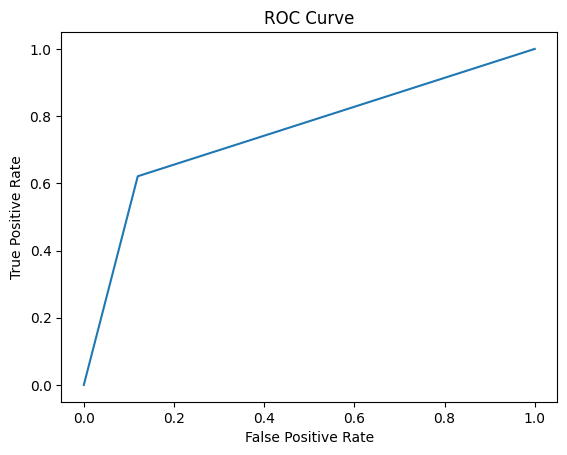

In [ ]:
#roc_curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()